In [30]:
from langchain_community.tools import tool
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from langchain_community import document_loaders
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage,SystemMessage
from typing import TypedDict,Annotated,Optional,Dict,Any
import requests
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import tool_node,tools_condition,ToolNode
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
import sqlite3
import tempfile
from __future__ import annotations
from langchain_community.vectorstores import FAISS


In [18]:
load_dotenv(dotenv_path=".env", override=True)
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
llm = ChatGroq(
    model="llama-3.3-70b-versatile",  
    api_key=GROQ_API_KEY  
)

In [19]:
class chatstate(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [21]:
from langchain_community.embeddings import SentenceTransformerEmbeddings
embeddings = SentenceTransformerEmbeddings(
    model_name="all-MiniLM-L6-v2"
)


# -------------------
# 2. PDF retriever store (per thread)
# -------------------
_THREAD_RETRIEVERS: Dict[str, Any] = {}
_THREAD_METADATA: Dict[str, dict] = {}


def _get_retriever(thread_id: Optional[str]):
    """Fetch the retriever for a thread if available."""
    if thread_id and thread_id in _THREAD_RETRIEVERS:
        return _THREAD_RETRIEVERS[thread_id]
    return None


def ingest_pdf(file_bytes: bytes, thread_id: str, filename: Optional[str] = None) -> dict:
    """
    Build a FAISS retriever for the uploaded PDF and store it for the thread.

    Returns a summary dict that can be surfaced in the UI.
    """
    if not file_bytes:
        raise ValueError("No bytes received for ingestion.")

    with tempfile.NamedTemporaryFile(delete=False, suffix=".pdf") as temp_file:
        temp_file.write(file_bytes)
        temp_path = temp_file.name

    try:
        loader = PyPDFLoader(temp_path)
        docs = loader.load()

        splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000, chunk_overlap=200, separators=["\n\n", "\n", " ", ""]
        )
        chunks = splitter.split_documents(docs)

        vector_store = FAISS.from_documents(chunks, embeddings)
        retriever = vector_store.as_retriever(
            search_type="similarity", search_kwargs={"k": 4}
        )

        _THREAD_RETRIEVERS[str(thread_id)] = retriever
        _THREAD_METADATA[str(thread_id)] = {
            "filename": filename or os.path.basename(temp_path),
            "documents": len(docs),
            "chunks": len(chunks),
        }

        return {
            "filename": filename or os.path.basename(temp_path),
            "documents": len(docs),
            "chunks": len(chunks),
        }
    finally:
        # The FAISS store keeps copies of the text, so the temp file is safe to remove.
        try:
            os.remove(temp_path)
        except OSError:
            pass


C:\Users\QHS 006\AppData\Local\Temp\ipykernel_13828\1670126661.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1593.00it/s]


In [22]:
search_tool = DuckDuckGoSearchRun(region="us-en")


@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}

        return {
            "first_num": first_num,
            "second_num": second_num,
            "operation": operation,
            "result": result,
        }
    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    )
    r = requests.get(url)
    return r.json()


@tool
def rag_tool(query: str, thread_id: Optional[str] = None) -> dict:
    """
    Retrieve relevant information from the uploaded PDF for this chat thread.
    Always include the thread_id when calling this tool.
    """
    retriever = _get_retriever(thread_id)
    if retriever is None:
        return {
            "error": "No document indexed for this chat. Upload a PDF first.",
            "query": query,
        }

    result = retriever.invoke(query)
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata,
        "source_file": _THREAD_METADATA.get(str(thread_id), {}).get("filename"),
    }


tools = [search_tool, get_stock_price, calculator, rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
def chat(state:chatstate) -> chatstate:
    message=state['messages']
    response=llm_with_tools.invoke(message)
    return {'messages':[response]}
tool=ToolNode(tools)
    

In [29]:
conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [26]:
graph=StateGraph(chatstate)
graph.add_node('chat',chat)
graph.add_node('tool',tool)
graph.add_edge(START,'chat')
graph.add_conditional_edges('chat',tool)
graph.add_edge('tool','chat')
graph.add_edge('chat',END)

In [27]:
chatbot=graph.compile()

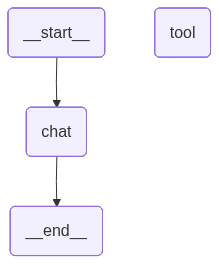

In [28]:
chatbot